In [1]:
#naive bayes can have continuous and categorical
#and for svm have to be numerical

In [2]:
#svm adds a new dimension to the data that reveals a linear boundary!

In [3]:
#easily interpretable probabilities
#geometric interpretation

#naive bayes is easier
#svm is more computationally expensive

#the svm has many hyperparameters!

#positive result from the test 5%
#probability of having the disease given a positive test result 3.6%

#p(k) has the desease regardless of any test.

#positive test result

#0.9 is the likelihood

#0.2 % 0.002

p topic given words = p words given topic * p topic
                        /
                        p words

Politics Sports Movies Other

P(opinion|topic) * P(score|topic) * P(game|topic) * P(cinema|topic) * P(topic)

p(words|topic) likelihood

#hay una correlacion y eso no va a funcionar

p(politics|words) ∝ p(words|politics) × p(politics)

p(sports|words) ∝ p(words|sports) × p(sports)

p(movies|words) ∝ p(words|movies) × p(movies)

p(other|words) ∝ p(words|other) × p(other)

In [4]:
library(mlr)

Loading required package: ParamHelpers



In [5]:
library(tidyverse)

── Attaching core tidyverse packages ────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.2
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [6]:
data(HouseVotes84, package = 'mlbench')

In [7]:
?mlbench::HouseVotes84

HouseVotes84 {mlbench},R Documentation
1,"Class Name: 2 (democrat, republican)"
2,"handicapped-infants: 2 (y,n)"
3,"water-project-cost-sharing: 2 (y,n)"
4,"adoption-of-the-budget-resolution: 2 (y,n)"
5,"physician-fee-freeze: 2 (y,n)"
6,"el-salvador-aid: 2 (y,n)"
7,"religious-groups-in-schools: 2 (y,n)"
8,"anti-satellite-test-ban: 2 (y,n)"
9,"aid-to-nicaraguan-contras: 2 (y,n)"
10,"mx-missile: 2 (y,n)"


In [8]:
votestib<-as_tibble(HouseVotes84)
votestib

Class,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16
<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>
republican,n,y,n,y,y,y,n,n,n,y,NA,y,y,y,n,y
republican,n,y,n,y,y,y,n,n,n,n,n,y,y,y,n,NA
democrat,NA,y,y,NA,y,y,n,n,n,n,y,n,y,y,n,n
democrat,n,y,y,n,NA,y,n,n,n,n,y,n,y,n,n,y
democrat,y,y,y,n,y,y,n,n,n,n,y,NA,y,y,y,y
democrat,n,y,y,n,y,y,n,n,n,n,n,n,y,y,y,y
democrat,n,y,n,y,y,y,n,n,n,n,n,n,NA,y,y,y
republican,n,y,n,y,y,y,n,n,n,n,n,n,y,y,NA,y
republican,n,y,n,y,y,y,n,n,n,n,n,y,y,y,n,y


In [9]:
map_dbl(votestib, ~sum(is.na(.)))

Class    V1    V2    V3    V4    V5    V6    V7    V8    V9   V10   V11   V12 
    0    12    48    11    11    15    11    14    15    22     7    21    31 
  V13   V14   V15   V16 
   25    17    28   104

In [10]:
votesuntidy<-gather(votestib, "Variable", "Value", -Class)
votesuntidy

Class,Variable,Value
<fct>,<chr>,<chr>
republican,V1,n
republican,V1,n
democrat,V1,NA
democrat,V1,n
democrat,V1,y
democrat,V1,n
democrat,V1,n
republican,V1,n
republican,V1,n


Saving 6.67 x 6.67 in image


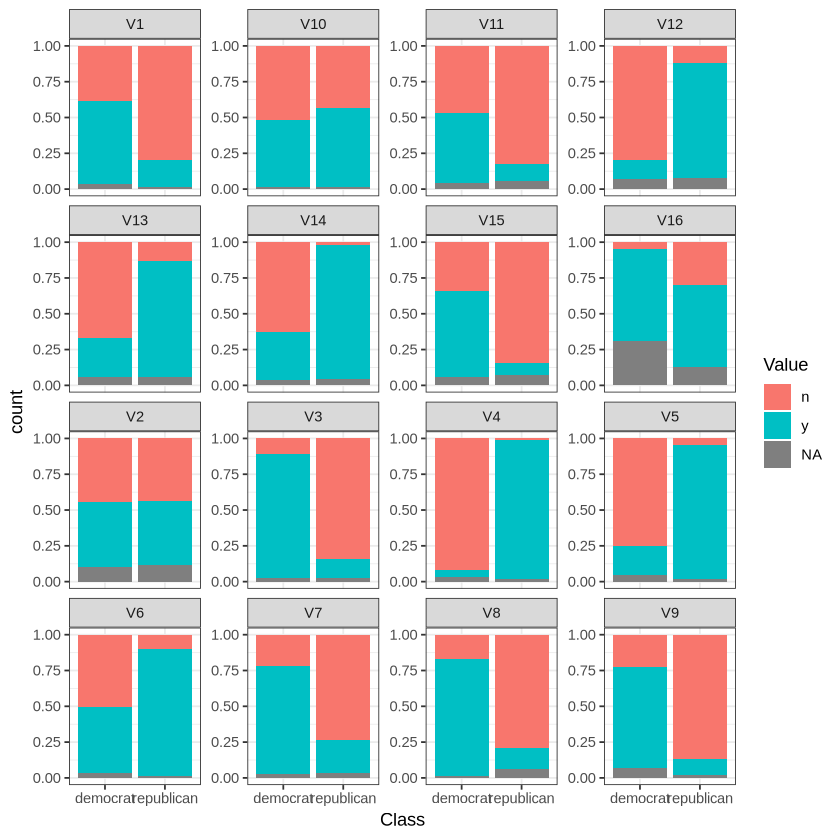

In [11]:
#qieres hacer un analisis de los temas y ver quien es democrata o republicano en base a votos
(
    ggplot(votesuntidy, aes(Class, fill= Value)) + 
    facet_wrap(~Variable, scales = 'free_y') + 
    geom_bar(position = 'fill') + 
    theme_bw()
)
ggsave('political.png')

In [12]:
votestask = makeClassifTask(data = votestib, target = 'Class')

Warning message in makeTask(type = type, data = data, weights = weights, blocking = blocking, :
“Provided data is not a pure data.frame but from class tbl_df, hence it will be converted.”


In [13]:
bayes<-makeLearner('classif.naiveBayes')

In [16]:
#it can handle missing data
model<-train(bayes,votestask)
model

Model for learner.id=classif.naiveBayes; learner.class=classif.naiveBayes
Trained on: task.id = votestib; obs = 435; features = 16
Hyperparameters: 

In [20]:
kfold<-makeResampleDesc('RepCV', folds=10, reps=50,stratify = TRUE)

In [23]:
bayescv<-resample(bayes, votestask, kfold, measures = list(mmce,acc,fpr,fnr))

Resampling: repeated cross-validation

Measures:             mmce      acc       fpr       fnr       

[Resample] iter 1:    0.1363636 0.8636364 0.0588235 0.1851852 

[Resample] iter 2:    0.1190476 0.8809524 0.1875000 0.0769231 

[Resample] iter 3:    0.0681818 0.9318182 0.1176471 0.0370370 

[Resample] iter 4:    0.1395349 0.8604651 0.0588235 0.1923077 

[Resample] iter 5:    0.0681818 0.9318182 0.0588235 0.0740741 

[Resample] iter 6:    0.1363636 0.8636364 0.1176471 0.1481481 

[Resample] iter 7:    0.0909091 0.9090909 0.0000000 0.1481481 

[Resample] iter 8:    0.0909091 0.9090909 0.0588235 0.1111111 

[Resample] iter 9:    0.0697674 0.9302326 0.1250000 0.0370370 

[Resample] iter 10:   0.0465116 0.9534884 0.0000000 0.0769231 

[Resample] iter 11:   0.0465116 0.9534884 0.0000000 0.0769231 

[Resample] iter 12:   0.1136364 0.8863636 0.1176471 0.1111111 

[Resample] iter 13:   0.1818182 0.8181818 0.1176471 0.2222222 

[Resample] iter 14:   0.1395349 0.8604651 0.1764706 0.1153846 

[

In [25]:
bayescv$aggr

mmce.test.mean  acc.test.mean  fpr.test.mean  fnr.test.mean 
    0.09869762     0.90130238     0.08273529     0.10874929

In [28]:
politician<-tibble(V1 = "n", V2 = "n", V3 = "y", V4 = "n", V5 = "n",
V6 = "y", V7 = "y", V8 = "y", V9 = "y", V10 = "y",
V11 = "n", V12 = "y", V13 = "n", V14 = "n",
V15 = "y", V16 = "n")
politician

V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
n,n,y,n,n,y,y,y,y,y,n,y,n,n,y,n


In [31]:
pp<-predict(model, newdata = politician)

Warning message in predict.WrappedModel(model, newdata = politician):
“Provided data for prediction is not a pure data.frame but from class tbl_df, hence it will be converted.”


In [33]:
getPredictionResponse(pp)

[1] democrat
Levels: democrat republican

#it has no hyperparameters!
#how it can add an extra dimension to data to make the classes linearly separable

#will learn a linear hyperplane

#support vectors margin

#straight line 

#support vectors touch the margin

#si mueves los support vectors se mueve el hyperplano

#si mueves los otros no importa

wx + b = 0

w = -b -a 1
    1  x  y

w * x = 0 son orthogonales

wx + b = +1
wx + b = -1

2/
|w|

el caso a abajo de margen 1 y el caso b arriba del margen 2

#maximize the margin

#hard margin
#soft margin hyperparameter

en el otro solo estaba el plano pero aqui hay un add on 
informacion artificial jeje y como sabes que esta bien

informacion artificial es un kernel!

lda y svm son opuestos!

linear kernel no kernel

best performing kernel